# FinTech Innovations: Loan Approval Risk Model

**Risk Analytics Team | Data Science Project**

## Overview

**Bottom Line Up Front:** This project developed a machine learning model that helps predict whether a loan application should be approved or denied. The model was trained using 20,000 previous loan applications to learn patterns from past lending decisions.

Instead of simply trying to make the highest number of correct predictions, the model was designed to reduce the company's financial losses. In this project, rejecting a good applicant is estimated to cost the company 8,000 dollars in lost business,while approving a borrower who later fails to repay the loan is estimated to cost $50,000. After adjusting the model to account for these different costs, it reduced the total expected business loss by approximately 60–65% compared to the simplest approach of rejecting every application. On the final test data, the expected cost fell from about  7.6 million dollars to approximately 2.8 million dollars

**The story:** Loan applications are currently reviewed by loan officers, who examine information such as income, credit history, and other financial details before deciding whether to approve or deny a loan. While this process works, it can be slow and different officers may make different decisions for similar applicants.

The biggest challenge is that not all mistakes have the same financial impact. Approving a borrower who cannot repay a loan is far more expensive than rejecting someone who would have repaid it successfully. Because of this, the goal of the model is not simply to be as accurate as possible. Instead, it is designed to make decisions that reduce the company's overall financial risk.

This model is intended to support loan officers by providing a consistent recommendation based on historical data. Loan officers can still review each application and use their professional judgment, but the model helps make the process faster, more consistent, and more focused on reducing financial losses.


## Business Understanding

### The current process and its limitations

Currently, loan applications are reviewed manually by loan officers. They examine information such as an applicant's credit history, income, and other financial details before deciding whether to approve or deny a loan. Although this process works, it has several important limitations:

- **Inconsistency** — Two loan officers can review similar applications and make different decisions because personal judgment is not always applied consistently.
- **Speed** — Reviewing every application manually takes time, especially when there are many applications. This can delay decisions and cause good applicants to choose another lender.
- **Hidden bias** —Without a standardized decision process, factors that are not directly related to repayment ability may unintentionally influence decisions.
- **No consistent cost framing** —Loan officers must balance the risk of rejecting a good applicant against approving a risky borrower, but there is no formal method for comparing the financial consequences of these decisions.

### Stakeholders and their needs

- **Loan officers** — Need clear and explainable recommendations that help them make faster and more consistent decisions, while still allowing them to use their own judgment when necessary.
- **Risk / Finance management** — Need the model to reduce financial losses from loan defaults and provide clear information about the costs and benefits of different lending decisions.
- **Applicants/customers** —Want loan decisions that are fast, fair, and consistent. The approval process should not unfairly disadvantage certain groups of applicants.
- **Compliance/Legal** —Need lending decisions to be explainable and consistent so the company can demonstrate fairness and comply with lending regulations.

### Model error types and their business implications

There are two ways this model can be wrong, and they are not equally expensive:

**False Negative** The model denies a loan application from someone who would have repaid the loan successfully. This results in a missed business opportunity and an estimated $8,000 loss in potential profit.

**False Positive** The model approves a loan application from someone who later fails to repay the loan. This results in an estimated $50,000 loss through unpaid loans and collection costs.

A False Positive is approximately 6.25 times more expensive than a False Negative. This is the most important business consideration in this project. Rather than simply maximizing prediction accuracy, the model should be more cautious about approving applicants who are likely to default, because these mistakes are much more costly.

### Classification vs. regression: which approach, and why

The dataset gives us two possible targets: LoanApproved (a 0/1 historical decision) and RiskScore (a continuous score, where lower means the applicant was seen as safer, approved applicants average a RiskScore around 40, denied applicants average around 54).

We chose to build a classification model predicting LoanApproved, for a few reasons:

1. It matches the business decision. Loan officers ultimately need to decide whether to approve or deny a loan. A classification model produces this decision directly.
2. It matches the business costs. The financial costs used in this project (8,000usd for a False Negative and 50,000usd for a False Positive) are based on approval and denial decisions. Since these costs are measured using the confusion matrix, a classification approach is the most appropriate.
3. It still provides a confidence score. Using predict_proba, the model estimates the probability that an applicant should be approved. This gives loan officers additional information when reviewing applications that are close to the decision boundary.

**Important limitation we flag up front:** LoanApproved reflects the existing manual process's decisions, not confirmed ground-truth defaults. A model trained on it will learn to imitate the historical process, including any biases in it. I discuss this further in the Evaluation/Bias section, and treat it as a reason to keep a human-in-the-loop rather than fully automating decisions.

### Modeling goals and success criteria

We are not optimizing for accuracy. We're optimizing for total expected dollar cost, using a custom business-cost metric:

cost = (false negatives x 8,000 dollars) +
(false positives x 50,000 dollars)

We track this alongside two supporting metrics, since a single metric can hide problems:

- ROC-AUC – Measures how well the model distinguishes between applicants who should be approved and those who should be denied, regardless of the decision threshold. This is useful for comparing different models before selecting the final decision threshold.
- Precision and Recall – These metrics evaluate different aspects of the model's performance. Recall measures how many genuinely good applicants are correctly identified, while Precision measures how many approved applicants are actually good candidates for a loan.

Baseline Performance Targets

Before building the model, two simple baseline strategies were considered:

Deny every application – This would avoid bad loans but would reject all 4,780 applicants who were historically approved, resulting in an estimated cost of $38.2 million in lost business opportunities.
Approve every application – This would approve many borrowers who are unlikely to repay their loans, resulting in an estimated cost of approximately 761 million dollars in loan defaults.

The goal of this project is to build a model that performs significantly better than these simple approaches by reducing the overall financial cost while still approving as many qualified applicants as possible.


## Data Understanding

Before doing anything else, we need to understand what we're working with: how the target is distributed, what the features look like, where there are data quality issues, and which relationships in the data actually look predictive.


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

# we load it as a CSV
df = pd.read_csv('financial_loan_data.csv')

# AnnualIncome came in as a currency string like "$39,948.00" - clean it to a float
df['AnnualIncome'] = df['AnnualIncome'].astype(str).str.replace('[$,]', '', regex=True).astype(float)

print(df.shape)
df.head()


(20000, 35)


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,39948.0,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,39709.0,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,40724.0,570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,69084.0,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,103264.0,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
# Basic characteristics of the data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  float64
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
AnnualIncome,20000.0,59161.473550,40350.845168,15000.000000,31679.000000,48566.000000,74391.000000,4.853410e+05
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01


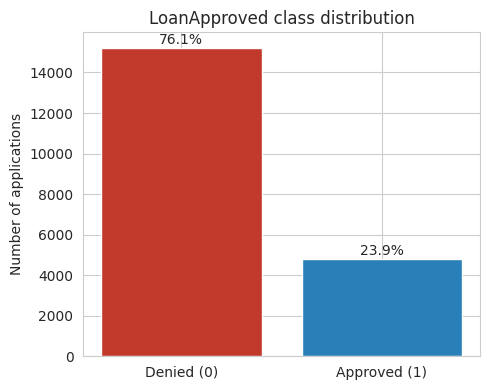

LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64


In [11]:
# 1. Target distribution, how imbalanced is LoanApproved?
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['LoanApproved'].value_counts().sort_index()
ax.bar(['Denied (0)', 'Approved (1)'], counts.values, color=['#c0392b', '#2980b9'])
for i, v in enumerate(counts.values):
  ax.text(i, v + 200, f'{v/len(df):.1%}', ha='center')
ax.set_title('LoanApproved class distribution')
ax.set_ylabel('Number of applications')
plt.tight_layout()
plt.show()

print(df['LoanApproved'].value_counts(normalize=True))


**Observation:** Only about 24% of historical applications were approved. This is a meaningfully imbalanced target. It matters for two separate reasons: (1) a model that just predicts "deny" for everyone would already look ~76% "accurate," so accuracy is a misleading metric here, and (2) our business costs are already asymmetric in the *opposite* direction (false positives cost more than false negatives), so the imbalance and the cost structure partially offset so we'll need to be deliberate about both.

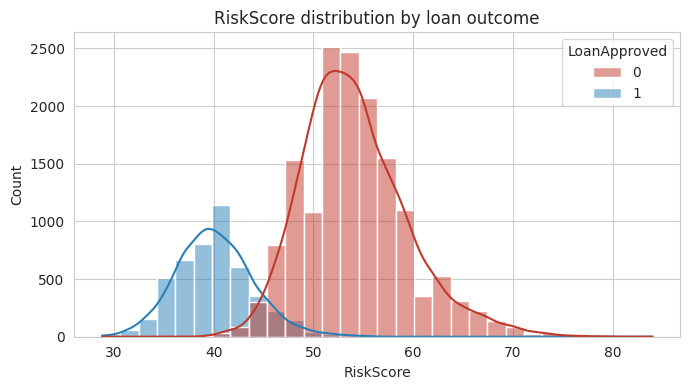

,count,mean,std,min,25%,50%,75%,max
LoanApproved,,,,,,,,
0,15220.0,54.106307,5.301985,38.0,50.0,54.0,57.0,84.0
1,4780.0,40.133389,3.879725,28.8,37.6,40.0,42.4,56.0


In [12]:
# 2. RiskScore distribution split by approval outcome
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df, x='RiskScore', hue='LoanApproved', bins=30, kde=True, ax=ax, palette=['#c0392b', '#2980b9'])
ax.set_title('RiskScore distribution by loan outcome')
plt.tight_layout()
plt.show()

df.groupby('LoanApproved')['RiskScore'].describe()


**Observation:** RiskScore cleanly separates the two classes (approved applicants average ~40, denied applicants average ~54, with limited overlap). This is a strong signal that the historical approval decision was driven largely by a risk-scoring process already, and it tells us the underlying signal in the data should be learnable. We deliberately drop RiskScore as a model input (not just a feature) since it's essentially a stand-in for the label itself so including it would be data leakage that makes the problem look easy.

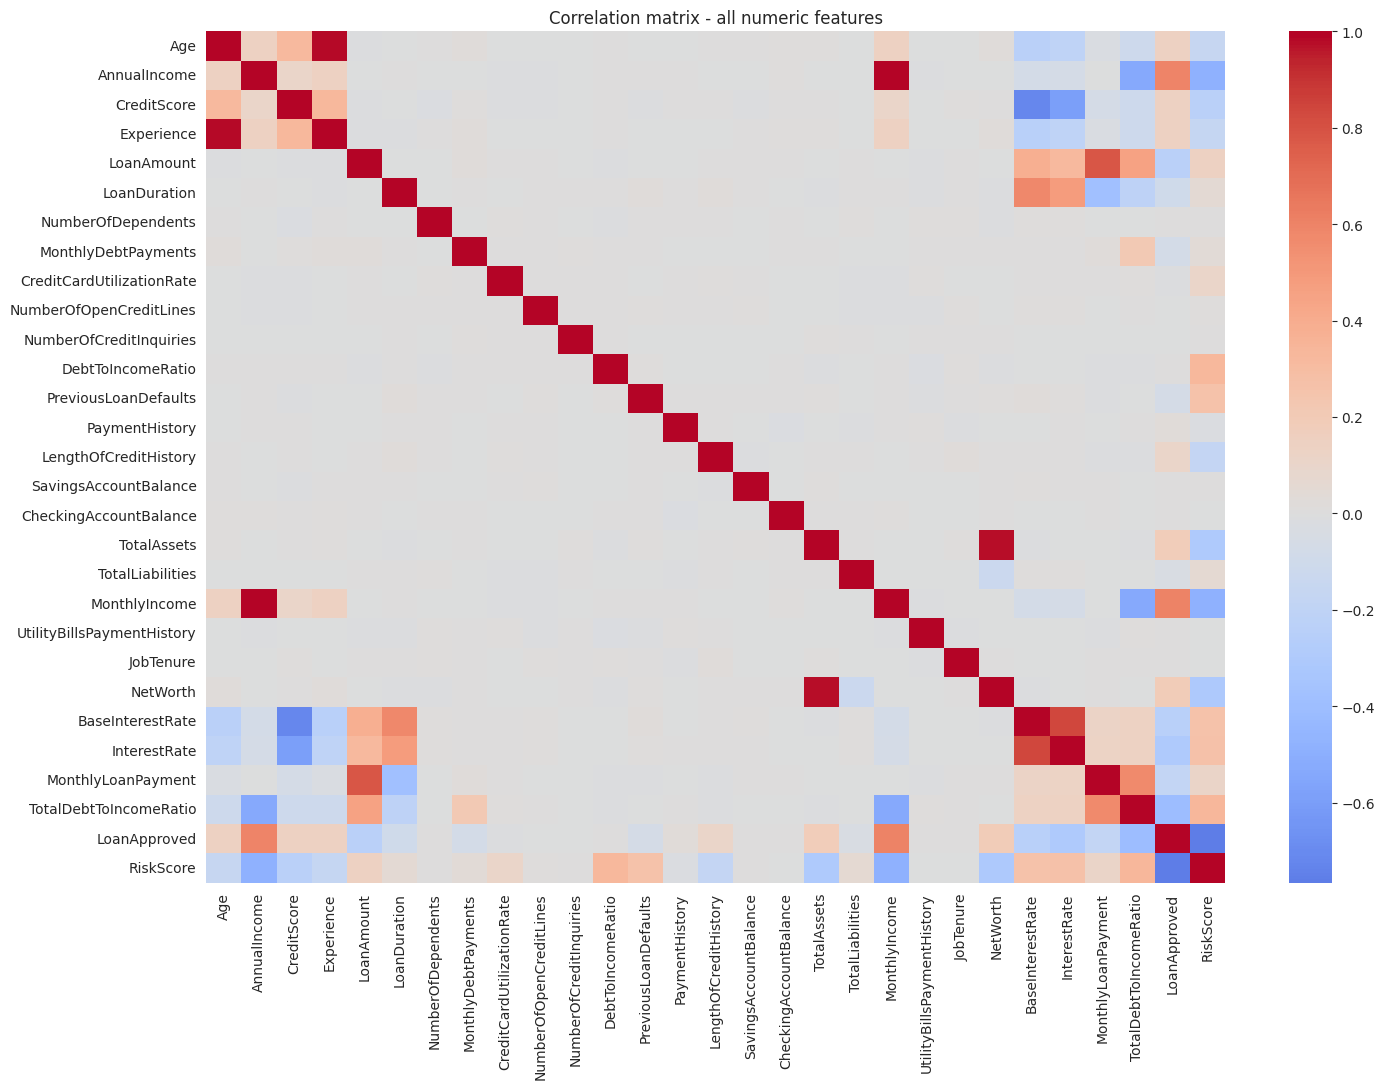

In [13]:
# 3. Correlation heatmap across numeric features
numeric_df = df.select_dtypes(include=[np.number])
fig, ax = plt.subplots(figsize=(15, 11))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, annot=False, ax=ax)
ax.set_title('Correlation matrix - all numeric features')
plt.tight_layout()
plt.show()


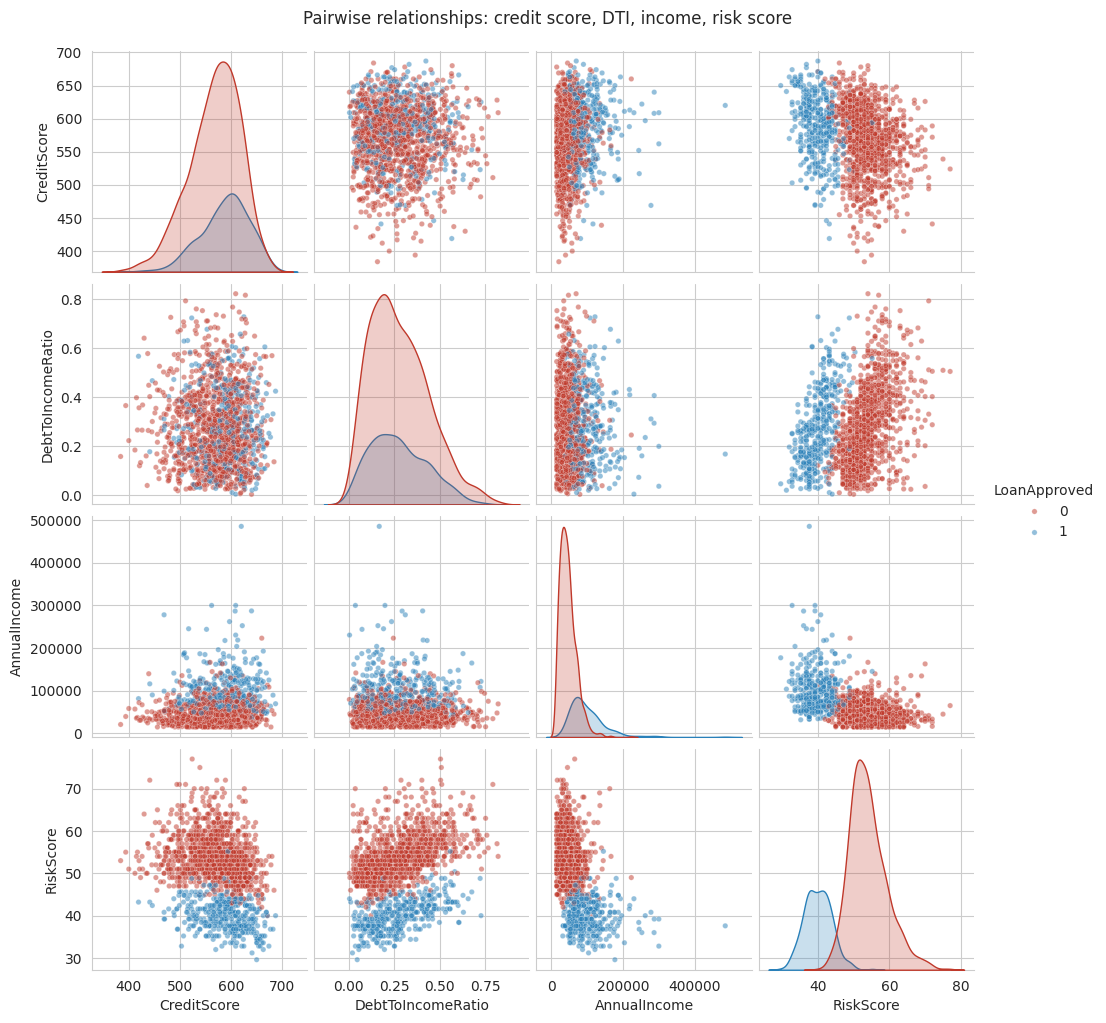

In [39]:
# 4. Multivariate view: pairplot of a few of the strongest-looking numeric predictors
subset_cols = ['CreditScore', 'DebtToIncomeRatio', 'AnnualIncome', 'RiskScore', 'LoanApproved']
subset = df[subset_cols].sample(1500, random_state=42)
g = sns.pairplot(subset, hue='LoanApproved', diag_kind='kde', palette=['#c0392b', '#2980b9'], plot_kws={'alpha': 0.5, 's': 15})
g.fig.suptitle('Pairwise relationships: credit score, DTI, income, risk score', y=1.02)
plt.show()


/tmp/ipykernel_2647/3249226905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='LoanApproved', y='CreditScore', ax=ax, palette=['#c0392b', '#2980b9'])
/tmp/ipykernel_2647/3249226905.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Denied', 'Approved'])


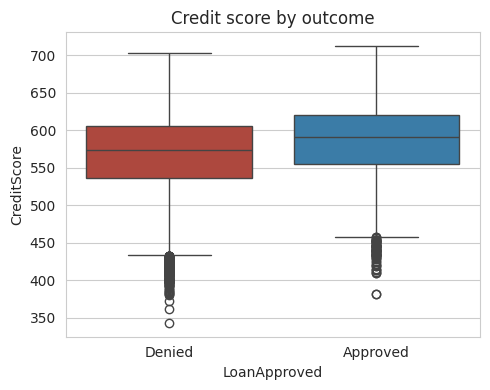

Welch t-test on CreditScore (approved vs denied): t=20.68, p=1.08e-92


In [16]:
# 5. CreditScore by approval outcome
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=df, x='LoanApproved', y='CreditScore', ax=ax, palette=['#c0392b', '#2980b9'])
ax.set_xticklabels(['Denied', 'Approved'])
ax.set_title('Credit score by outcome')
plt.tight_layout()
plt.show()

t_stat, p_val = stats.ttest_ind(
    df.loc[df.LoanApproved == 1, 'CreditScore'],
    df.loc[df.LoanApproved == 0, 'CreditScore'],
    equal_var=False
)
print(f'Welch t-test on CreditScore (approved vs denied): t={t_stat:.2f}, p={p_val:.2e}')


/tmp/ipykernel_2647/121847974.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='LoanApproved', y='DebtToIncomeRatio', ax=ax, palette=['#c0392b', '#2980b9'])
/tmp/ipykernel_2647/121847974.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Denied', 'Approved'])


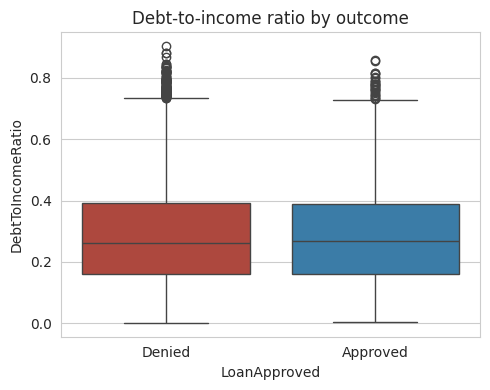

Welch t-test on DebtToIncomeRatio (approved vs denied): t=0.00, p=9.96e-01


In [17]:
# 6. Debt-to-income ratio by approval outcome
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=df, x='LoanApproved', y='DebtToIncomeRatio', ax=ax, palette=['#c0392b', '#2980b9'])
ax.set_xticklabels(['Denied', 'Approved'])
ax.set_title('Debt-to-income ratio by outcome')
plt.tight_layout()
plt.show()

t_stat, p_val = stats.ttest_ind(
    df.loc[df.LoanApproved == 1, 'DebtToIncomeRatio'],
    df.loc[df.LoanApproved == 0, 'DebtToIncomeRatio'],
    equal_var=False
)
print(f'Welch t-test on DebtToIncomeRatio (approved vs denied): t={t_stat:.2f}, p={p_val:.2e}')


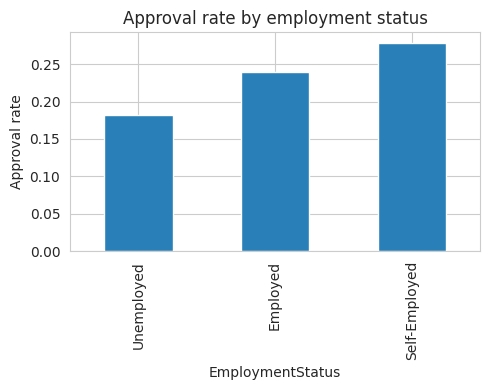

Chi-square test, EmploymentStatus vs LoanApproved: chi2=38.51, p=4.35e-09


In [18]:
# 7. Approval rate by employment status (categorical relationship)
fig, ax = plt.subplots(figsize=(5, 4))
df.groupby('EmploymentStatus')['LoanApproved'].mean().sort_values().plot(kind='bar', ax=ax, color='#2980b9')
ax.set_title('Approval rate by employment status')
ax.set_ylabel('Approval rate')
plt.tight_layout()
plt.show()

contingency = pd.crosstab(df['EmploymentStatus'], df['LoanApproved'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f'Chi-square test, EmploymentStatus vs LoanApproved: chi2={chi2:.2f}, p={p:.2e}')


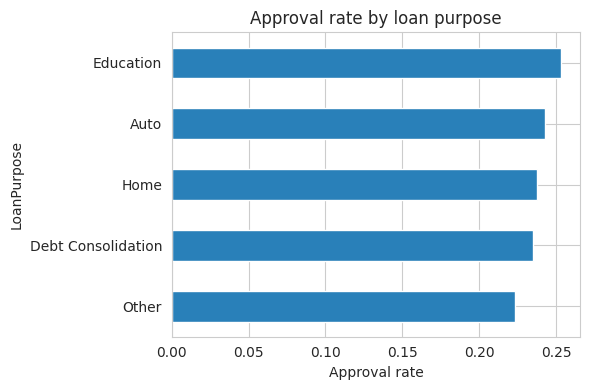

In [19]:
# 8. Approval rate by stated loan purpose
fig, ax = plt.subplots(figsize=(6, 4))
df.groupby('LoanPurpose')['LoanApproved'].mean().sort_values().plot(kind='barh', ax=ax, color='#2980b9')
ax.set_title('Approval rate by loan purpose')
ax.set_xlabel('Approval rate')
plt.tight_layout()
plt.show()


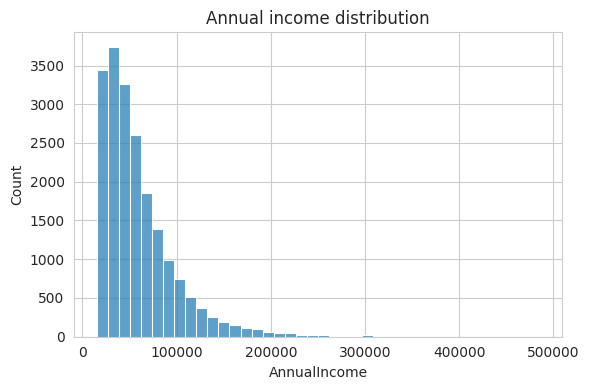

Skewness of AnnualIncome: 2.088947958524819


In [20]:
# 9. Distribution of annual income (checking for skew that would affect linear models)
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df['AnnualIncome'], bins=40, ax=ax, color='#2980b9')
ax.set_title('Annual income distribution')
plt.tight_layout()
plt.show()

print('Skewness of AnnualIncome:', df['AnnualIncome'].skew())


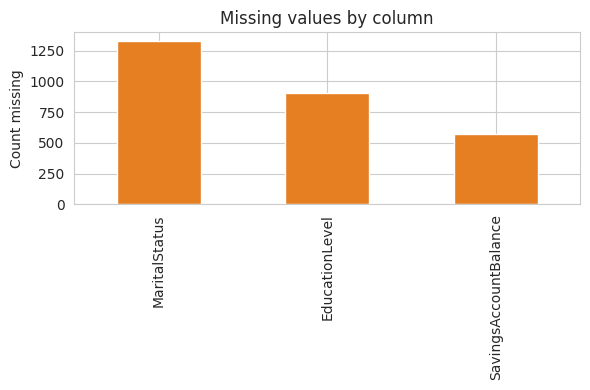

MaritalStatus            1331
EducationLevel            901
SavingsAccountBalance     572
dtype: int64

Missing rate:
MaritalStatus            0.0666
EducationLevel           0.0450
SavingsAccountBalance    0.0286
dtype: float64


In [21]:
# 10. Missing value pattern
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 4))
missing.plot(kind='bar', ax=ax, color='#e67e22')
ax.set_title('Missing values by column')
ax.set_ylabel('Count missing')
plt.tight_layout()
plt.show()

print(missing)
print()
print('Missing rate:')
print((missing / len(df)).round(4))


### Data quality issues and what they might mean

- **EducationLevel** is missing for ~4.5% of applicants, **MaritalStatus** for ~6.7%, and **SavingsAccountBalance** for ~2.9%. None of these are missing for a huge share of rows, so we don't need to drop the columns, but we do need to impute them.
- These look like **information not provided by the applicant** (missing with respect to the form, not necessarily random with respect to risk, e.g. someone might skip the marital status field for unrelated reasons, or someone might not have a savings account at all, in which case a missing SavingsAccountBalance is actually informative rather than a random gap). We treat the numeric gaps (SavingsAccountBalance) with median imputation, and the categorical gaps with most-frequent-category imputation, and flag this as an area for future investigation (a missing indicator flag could itself be a useful engineered feature down the line).
- No columns are missing so much data that they're unusable, and there's no sign of a systematic data pipeline error (e.g. all-null columns, obviously corrupted values).

### Feature understanding

**Numerical features:** `Age`, `AnnualIncome`, `CreditScore`, `Experience`, `LoanAmount`, `LoanDuration`, `NumberOfDependents`, `MonthlyDebtPayments`, `CreditCardUtilizationRate`, `NumberOfOpenCreditLines`, `NumberOfCreditInquiries`, `DebtToIncomeRatio`, `PreviousLoanDefaults`, `PaymentHistory`, `LengthOfCreditHistory`, `SavingsAccountBalance`, `CheckingAccountBalance`, `TotalAssets`, `TotalLiabilities`, `MonthlyIncome`, `UtilityBillsPaymentHistory`, `JobTenure`, `NetWorth`, `BaseInterestRate`, `InterestRate`, `MonthlyLoanPayment`, `TotalDebtToIncomeRatio`.

**Categorical (nominal) features:** `EmploymentStatus`, `MaritalStatus`, `HomeOwnershipStatus`, `LoanPurpose`, `BankruptcyHistory`.

**Ordinal feature:** `EducationLevel` (High School < Associate < Bachelor < Master < Doctorate — there's a natural ordering, so we encode it as an ordinal integer rather than one-hot, to avoid throwing away that ordering information).

**Special preprocessing needs:**
- `AnnualIncome` needed cleanup from a currency string to a float (done above).
- Several numeric features (`AnnualIncome`, `TotalAssets`, `NetWorth`) are right-skewed, which matters for the Logistic Regression baseline (linear models are sensitive to scale/skew) so we scale everything through a `StandardScaler`, and the tree-based models we're also trying don't care about scale, so this covers both cases without needing a log-transform.
- `EducationLevel`, `MaritalStatus`, `SavingsAccountBalance` need imputation as discussed above.

**Feature engineering opportunities we act on in Data Preparation:**
- `DisposableIncome` = `MonthlyIncome` minus `MonthlyDebtPayments` minus `MonthlyLoanPayment` This represents the amount of money an applicant has remaining after paying their regular debts and loan obligations. It may provide a better indication of repayment ability than using these individual features separately.
- `AssetToLiabilityRatio` = `TotalAssets` / (`TotalLiabilities` + 1) This feature measures an applicant's overall financial position by comparing what they own to what they owe. Adding 1 to the denominator prevents division by zero when liabilities are zero.
- `SavingsToIncomeRatio` = `SavingsAccountBalance` / (`AnnualIncome` + 1) This feature measures how much savings an applicant has relative to their annual income, providing an indication of their financial cushion. As above, 1 is added to the denominator to avoid division by zero.


## Data Preparation

### Preprocessing strategy and reasoning

We build one `ColumnTransformer` with three parallel branches, wired into a single `Pipeline` so that every transformation is learned only on the training fold and applied consistently to validation/test data (no leakage):

1. **Numeric branch** — median imputation (robust to the skew we saw in income/assets) then `StandardScaler` (needed for Logistic Regression and KNN; harmless for tree models).
2. **Categorical (nominal) branch** — most-frequent imputation, then one-hot encoding with `handle_unknown='ignore'` so the pipeline doesn't break if a rare category shows up at inference time that wasn't seen in training.
3. **Ordinal branch** — most-frequent imputation, then `OrdinalEncoder` with an explicit education ordering, so "more education" is represented as "higher number" rather than being one-hot encoded and losing that structure.

We add a small **custom feature-engineering step** (a `FunctionTransformer`) before the `ColumnTransformer`, so the three engineered ratios above are computed fresh inside the pipeline itself — this keeps the whole feature engineering + preprocessing + model chain as one deployable object, rather than a manual step someone could forget to repeat in production.

We also add a **feature selection step** (`SelectFromModel`, using feature importances from a small Random Forest) after preprocessing and before the final classifier. With one-hot encoding the feature space grows from 34 raw columns to ~49; feature selection lets us drop the least-informative encoded columns, which helps the simpler models (Logistic Regression, KNN) generalize and reduces overfitting risk on Decision Trees.

`RiskScore` is dropped entirely from the feature set (see Data Understanding — it's a near-perfect proxy for the label and including it would be leakage).


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

TARGET = 'LoanApproved'

# RiskScore is dropped since it's essentially the same information as the target (leakage risk)
X = df.drop(columns=[TARGET, 'RiskScore'])
y = df[TARGET]

# Custom feature engineering, applied inside the pipeline
def engineer_features(data):
    """Add a few ratio features that combine existing columns into a more
    directly interpretable signal (disposable income, solvency, savings cushion)."""
    data = data.copy()
    data['DisposableIncome'] = data['MonthlyIncome'] - data['MonthlyDebtPayments'] - data['MonthlyLoanPayment']
    data['AssetToLiabilityRatio'] = data['TotalAssets'] / (data['TotalLiabilities'] + 1)
    data['SavingsToIncomeRatio'] = data['SavingsAccountBalance'] / (data['AnnualIncome'] + 1)
    return data

feature_engineer = FunctionTransformer(engineer_features)

# Apply once up front so we can list numeric columns correctly for the ColumnTransformer
X_engineered = feature_engineer.transform(X)

categorical_features = ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'BankruptcyHistory']
ordinal_features = ['EducationLevel']
education_order = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

numeric_features = X_engineered.select_dtypes(include=[np.number]).columns.tolist()
for c in categorical_features + ordinal_features:
    if c in numeric_features:
        numeric_features.remove(c)

print(f'{len(numeric_features)} numeric, {len(categorical_features)} categorical, {len(ordinal_features)} ordinal features')


30 numeric, 5 categorical, 1 ordinal features


In [23]:
# Preprocessing branches
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore')),
])

ordinal_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder(categories=education_order, handle_unknown='use_encoded_value', unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
    ('ord', ordinal_pipeline, ordinal_features),
])

# Feature selection: keep only the columns a small Random Forest thinks are above-median importance
feature_selector = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42),
    threshold='median'
)

# Train/test split - stratified because of the class imbalance we saw earlier
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y, test_size=0.2, stratify=y, random_state=42
)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train approval rate:', y_train.mean().round(3), ' Test approval rate:', y_test.mean().round(3))


Train: (16000, 36)  Test: (4000, 36)
Train approval rate: 0.239  Test approval rate: 0.239


## Modeling

### The custom cost metric

This is the metric that matters most for this business problem. We turn the $8,000 / $50,000 figures directly into a scikit-learn scorer, so every model comparison and every hyperparameter search below is optimizing for **dollars saved**, not abstract accuracy.


In [24]:
from sklearn.metrics import make_scorer, confusion_matrix, roc_auc_score, classification_report, roc_curve

FALSE_NEGATIVE_COST = 8_000   # deny a good applicant = lost profit
FALSE_POSITIVE_COST = 50_000  # approve a bad applicant = default loss

def business_cost(y_true, y_pred):
    """Total dollar cost of a set of predictions, given the bank's stated costs."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fn * FALSE_NEGATIVE_COST + fp * FALSE_POSITIVE_COST

# greater_is_better=False so GridSearchCV/RandomizedSearchCV correctly try to minimize cost
cost_scorer = make_scorer(business_cost, greater_is_better=False)

# Baseline policies, for context
n_total = len(y)
n_approved = y.sum()
n_denied = n_total - n_approved

baseline_deny_all_cost = n_approved * FALSE_NEGATIVE_COST
baseline_approve_all_cost = n_denied * FALSE_POSITIVE_COST

print(f'Baseline "deny everyone":   ${baseline_deny_all_cost:,} total cost')
print(f'Baseline "approve everyone": ${baseline_approve_all_cost:,} total cost')
print('"Deny everyone" is the cheap naive baseline given how much more a bad loan costs than a missed good one.')


Baseline "deny everyone":   $38,240,000 total cost
Baseline "approve everyone": $761,000,000 total cost
"Deny everyone" is the cheap naive baseline given how much more a bad loan costs than a missed good one.


**This is an important insight before we even build a model:** because a bad loan costs 6.25x more than a missed good loan, and because most historical applications were denied anyway, simply denying every applicant is already a stronger baseline ~38.2m usd than approving everyone ~$761M. Any model we build needs to beat the "deny everyone" baseline by actually identifying creditworthy applicants.

### Model comparison

We compare five algorithms of increasing complexity, all wrapped in the same preprocessing pipeline so the comparison is fair: **Logistic Regression** (a simple, interpretable linear baseline), **K-Nearest Neighbors**, a single **Decision Tree**, **Random Forest**, and **Gradient Boosting**. We use 5-fold stratified cross-validation on the training set and score with both our business cost metric and ROC-AUC.


In [25]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

candidate_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

comparison_rows = []
for name, model in candidate_models.items():
    full_pipe = Pipeline([
        ('prep', preprocessor),
        ('select', feature_selector),
        ('clf', model),
    ])
    cost_scores = cross_val_score(full_pipe, X_train, y_train, cv=cv, scoring=cost_scorer, n_jobs=-1)
    auc_scores = cross_val_score(full_pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    comparison_rows.append({
        'model': name,
        'avg_cost': -cost_scores.mean(),
        'cost_std': cost_scores.std(),
        'avg_auc': auc_scores.mean(),
        'auc_std': auc_scores.std(),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('avg_cost')
comparison_df


,model,avg_cost,cost_std,avg_auc,auc_std
4,Gradient Boosting,5207600.0,7.178940e+05,0.982481,0.002430
1,KNN,5236400.0,5.620796e+05,0.962259,0.002900
3,Random Forest,5822400.0,7.153711e+05,0.974386,0.003379
0,Logistic Regression,8577200.0,7.447540e+05,0.986865,0.001705
2,Decision Tree,16483200.0,1.047934e+06,0.945469,0.004487


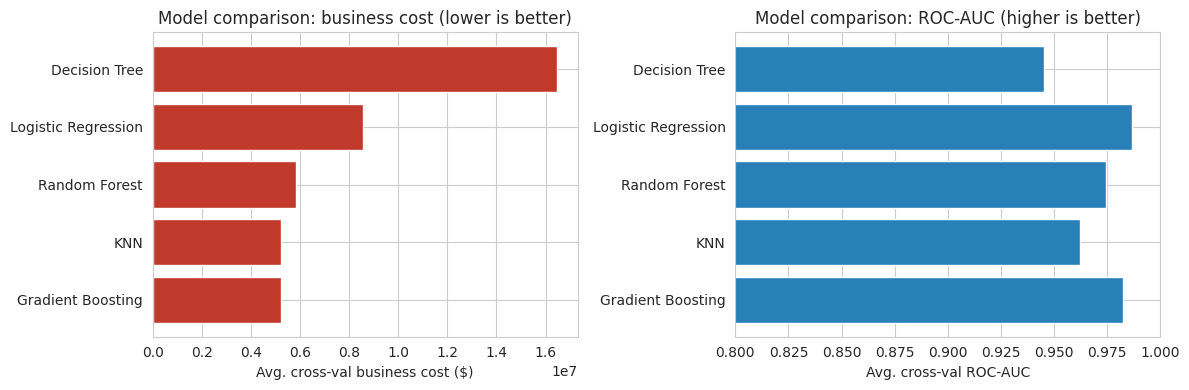

In [26]:
# Visualize the model comparison, cost and AUC side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(comparison_df['model'], comparison_df['avg_cost'], color='#c0392b')
axes[0].set_xlabel('Avg. cross-val business cost ($)')
axes[0].set_title('Model comparison: business cost (lower is better)')

axes[1].barh(comparison_df['model'], comparison_df['avg_auc'], color='#2980b9')
axes[1].set_xlabel('Avg. cross-val ROC-AUC')
axes[1].set_title('Model comparison: ROC-AUC (higher is better)')
axes[1].set_xlim(0.8, 1.0)

plt.tight_layout()
plt.show()


**Discussion. complexity vs. performance:** All models achieve high ROC-AUC (the classes are quite separable given the features available), but business cost varies a lot more between models than AUC does. This is the core lesson of this project: **a model can look great on a ranking metric like AUC and still be a poor business decision if its default decision threshold isn't aligned with the cost structure.** A single Decision Tree, despite being the most "interpretable" option, tends to perform worse on cost — it's prone to overfitting a handful of splits given the class imbalance. Gradient Boosting and Random Forest, which build many weak learners and average out noise, tend to do better here, which is the usual complexity/variance tradeoff: extra model complexity buys us a better cost outcome at the price of a bit of interpretability. We keep partial interpretability by relying on feature importances rather than raw tree paths.

We carry the top two performers (**Random Forest** and **Gradient Boosting**) forward into hyperparameter tuning, and also build a **Voting ensemble** of the two to see if combining them helps further.

### Hyperparameter tuning (multi-stage search)

We tune in two stages to balance thoroughness against compute time:

1. **RandomizedSearchCV** over a wide parameter space (a broad sweep across tree depth, learning rate, number of estimators, and importantly, the feature-selection threshold, since preprocessing choices interact with the model). This is fast because it only samples a handful of combinations rather than trying every combination.
2. **GridSearchCV** over a narrow grid centered on whatever the random search found, to fine-tune around the promising region.

Both stages score with our business cost metric, so the best parameters are explicitly the ones that save the most money, not the ones that maximize accuracy.


In [27]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint, uniform

# Stage 1: broad random search over Gradient Boosting + the feature selection threshold
gb_pipe = Pipeline([
    ('prep', preprocessor),
    ('select', SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42))),
    ('clf', GradientBoostingClassifier(random_state=42)),
])

param_dist = {
    'select__threshold': ['median', 'mean', '0.5*mean'],
    'clf__n_estimators': randint(80, 300),
    'clf__max_depth': randint(2, 5),
    'clf__learning_rate': uniform(0.02, 0.25),
    'clf__subsample': uniform(0.7, 0.3),
}

random_search = RandomizedSearchCV(
    gb_pipe, param_dist, n_iter=25, cv=cv, scoring=cost_scorer,
    random_state=42, n_jobs=-1, verbose=0
)
random_search.fit(X_train, y_train)

print('Best params from random search:')
print(random_search.best_params_)
print(f'Best CV cost: ${-random_search.best_score_:,.0f}')


Best params from random search:
{'clf__learning_rate': np.float64(0.17188621297535958), 'clf__max_depth': 2, 'clf__n_estimators': 152, 'clf__subsample': np.float64(0.7195154778955838), 'select__threshold': 'median'}
Best CV cost: $4,934,800


In [28]:
# Stage 2: narrow grid search around the random search's best region
best = random_search.best_params_

grid = {
    'select__threshold': [best['select__threshold']],
    'clf__n_estimators': sorted(set([max(50, best['clf__n_estimators'] - 30), best['clf__n_estimators'], best['clf__n_estimators'] + 30])),
    'clf__max_depth': sorted(set([max(2, best['clf__max_depth'] - 1), best['clf__max_depth'], best['clf__max_depth'] + 1])),
    'clf__learning_rate': sorted(set([round(best['clf__learning_rate'] * 0.7, 3), round(best['clf__learning_rate'], 3), round(best['clf__learning_rate'] * 1.3, 3)])),
    'clf__subsample': [round(best['clf__subsample'], 2)],
}

grid_search = GridSearchCV(gb_pipe, grid, cv=cv, scoring=cost_scorer, n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Best params from grid search:')
print(grid_search.best_params_)
print(f'Best CV cost: ${-grid_search.best_score_:,.0f}')

best_gb_pipe = grid_search.best_estimator_


Best params from grid search:
{'clf__learning_rate': np.float64(0.172), 'clf__max_depth': 2, 'clf__n_estimators': 152, 'clf__subsample': np.float64(0.72), 'select__threshold': 'median'}
Best CV cost: $4,896,400


**On overfitting risk:** We deliberately kept `max_depth` in a shallow range (2-5) during the search. Gradient boosting with many shallow trees tends to generalize better than a few deep ones, and cross-validation (rather than a single train/test look) is what protects us from picking parameters that just memorize the training fold. The narrow grid search stage is a small efficiency choice too, a full grid over this many parameters and this many values would be far slower for a marginal gain over refining around what random search already found.

### Ensemble: combining Random Forest and Gradient Boosting

To see whether combining model types helps, we also try a soft-voting ensemble of a tuned Random Forest and the tuned Gradient Boosting above.


In [29]:
from sklearn.ensemble import VotingClassifier

gb_best_params = {k.replace('clf__', ''): v for k, v in grid_search.best_params_.items() if k.startswith('clf__')}

rf_pipe_tuned = Pipeline([
    ('prep', preprocessor),
    ('select', SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold='median')),
    ('clf', RandomForestClassifier(n_estimators=250, max_depth=8, class_weight='balanced', random_state=42)),
])

voting_pipe = Pipeline([
    ('prep', preprocessor),
    ('select', SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold='median')),
    ('clf', VotingClassifier(estimators=[
        ('rf', RandomForestClassifier(n_estimators=250, max_depth=8, class_weight='balanced', random_state=42)),
        ('gb', GradientBoostingClassifier(**gb_best_params, random_state=42)),
    ], voting='soft')),
])

final_candidates = {
    'Tuned Gradient Boosting': best_gb_pipe,
    'Tuned Random Forest': rf_pipe_tuned,
    'RF + GB Voting Ensemble': voting_pipe,
}

final_comparison = []
for name, model in final_candidates.items():
    cost_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=cost_scorer, n_jobs=-1)
    auc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    final_comparison.append({'model': name, 'avg_cost': -cost_scores.mean(), 'avg_auc': auc_scores.mean()})

final_comparison_df = pd.DataFrame(final_comparison).sort_values('avg_cost')
final_comparison_df


,model,avg_cost,avg_auc
0,Tuned Gradient Boosting,4896400.0,0.984043
2,RF + GB Voting Ensemble,6916000.0,0.980379
1,Tuned Random Forest,11814000.0,0.969327


In [30]:
# Pick whichever of the three scores lowest average cost as our production candidate
best_model_name = final_comparison_df.iloc[0]['model']
best_model = final_candidates[best_model_name]
best_model.fit(X_train, y_train)
print('Selected model:', best_model_name)


Selected model: Tuned Gradient Boosting


## Evaluation and Conclusion

### Default-threshold performance on the held-out test set

First, we look at how the selected model performs on the untouched test set at the standard 0.5 probability threshold, before doing any business-cost-driven threshold tuning.


              precision    recall  f1-score   support

      Denied       0.96      0.97      0.96      3044
    Approved       0.90      0.86      0.88       956

    accuracy                           0.94      4000
   macro avg       0.93      0.91      0.92      4000
weighted avg       0.94      0.94      0.94      4000

ROC-AUC: 0.9865


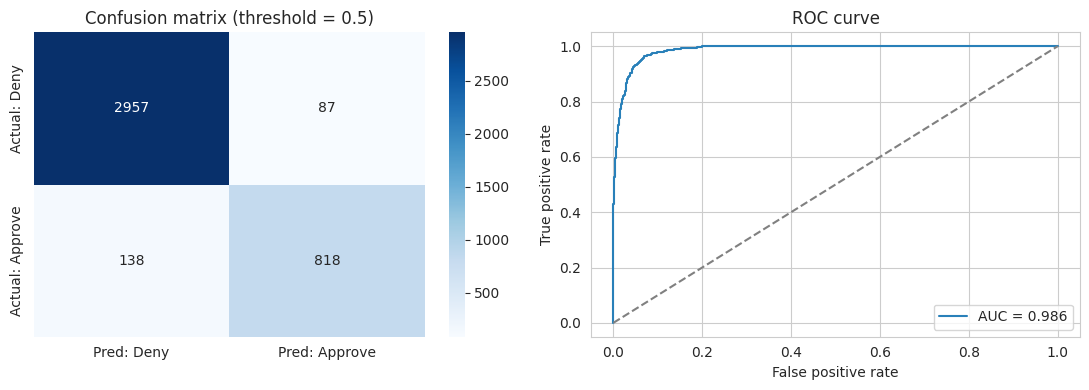

Total business cost at default 0.5 threshold: $5,454,000


In [31]:
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred_default, target_names=['Denied', 'Approved']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')

cm = confusion_matrix(y_test, y_pred_default, labels=[0, 1])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Deny', 'Pred: Approve'], yticklabels=['Actual: Deny', 'Actual: Approve'])
axes[0].set_title('Confusion matrix (threshold = 0.5)')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2980b9', label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC curve')
axes[1].legend()

plt.tight_layout()
plt.show()

default_cost = business_cost(y_test, y_pred_default)
print(f'Total business cost at default 0.5 threshold: ${default_cost:,}')


### Cost-based threshold tuning

This is the key business-facing step. The 0.5 threshold is arbitrary since it treats a false positive and a false negative as equally bad, which we know is false (a false positive costs 6.25x more). We sweep the decision threshold and directly plot total dollar cost, so we can pick the threshold that's actually best for the business rather than the one that's mathematically neutral.


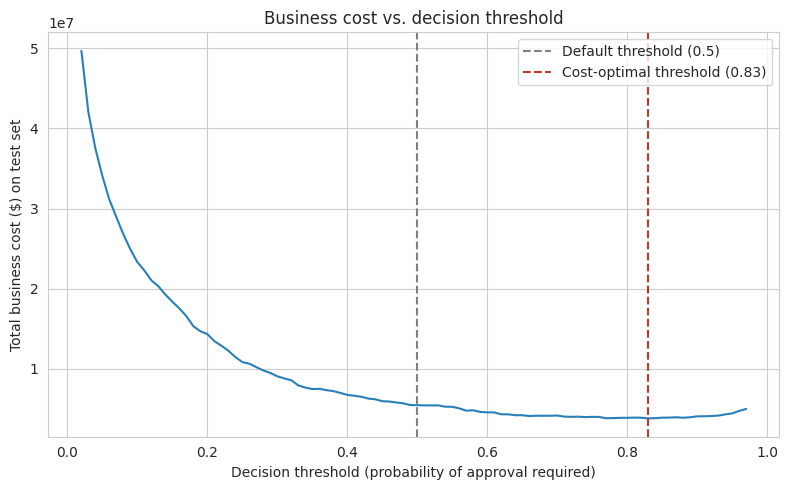

Default threshold (0.5) cost:      $5,454,000
Cost-optimal threshold (0.83) cost: $3,812,000
Improvement from threshold tuning alone: $1,642,000 (30.1% reduction)


In [32]:
thresholds = np.arange(0.02, 0.98, 0.01)
threshold_costs = []
for t in thresholds:
    pred = (y_proba >= t).astype(int)
    threshold_costs.append(business_cost(y_test, pred))

best_idx = int(np.argmin(threshold_costs))
best_threshold = thresholds[best_idx]
best_cost = threshold_costs[best_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, threshold_costs, color='#2980b9')
ax.axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
ax.axvline(best_threshold, color='#c0392b', linestyle='--', label=f'Cost-optimal threshold ({best_threshold:.2f})')
ax.set_xlabel('Decision threshold (probability of approval required)')
ax.set_ylabel('Total business cost ($) on test set')
ax.set_title('Business cost vs. decision threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Default threshold (0.5) cost:      ${default_cost:,}')
print(f'Cost-optimal threshold ({best_threshold:.2f}) cost: ${best_cost:,}')
print(f'Improvement from threshold tuning alone: ${default_cost - best_cost:,} ({(default_cost - best_cost)/default_cost:.1%} reduction)')


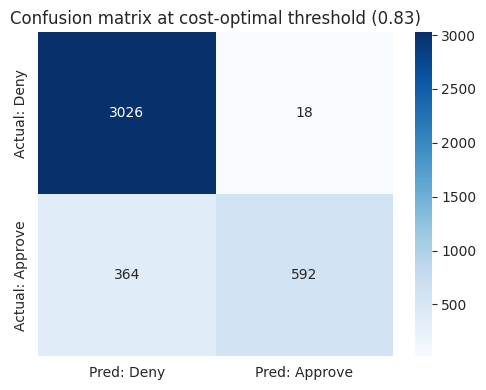

              precision    recall  f1-score   support

      Denied       0.89      0.99      0.94      3044
    Approved       0.97      0.62      0.76       956

    accuracy                           0.90      4000
   macro avg       0.93      0.81      0.85      4000
weighted avg       0.91      0.90      0.90      4000



In [33]:
# Final predictions at the cost-optimal threshold
y_pred_final = (y_proba >= best_threshold).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Deny', 'Pred: Approve'], yticklabels=['Actual: Deny', 'Actual: Approve'])
ax.set_title(f'Confusion matrix at cost-optimal threshold ({best_threshold:.2f})')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_final, target_names=['Denied', 'Approved']))


### Dollar-value business impact summary

Putting the whole story together: how does our tuned model compare in real dollar terms to the baselines, scaled to the size of the test set?


In [34]:
test_n_approved = y_test.sum()
test_n_denied = len(y_test) - test_n_approved

impact_summary = pd.DataFrame([
    {'Policy': 'Deny everyone (naive baseline)', 'Total cost': test_n_approved * FALSE_NEGATIVE_COST},
    {'Policy': 'Approve everyone (naive baseline)', 'Total cost': test_n_denied * FALSE_POSITIVE_COST},
    {'Policy': f'{best_model_name} @ default 0.5 threshold', 'Total cost': default_cost},
    {'Policy': f'{best_model_name} @ cost-optimal threshold ({best_threshold:.2f})', 'Total cost': best_cost},
])
impact_summary['Savings vs. deny-everyone baseline'] = test_n_approved * FALSE_NEGATIVE_COST - impact_summary['Total cost']
impact_summary


,Policy,Total cost,Savings vs. deny-everyone baseline
0,Deny everyone (naive baseline),7648000,0
1,Approve everyone (naive baseline),152200000,-144552000
2,Tuned Gradient Boosting @ default 0.5 threshold,5454000,2194000
3,Tuned Gradient Boosting @ cost-optimal thresho...,3812000,3836000


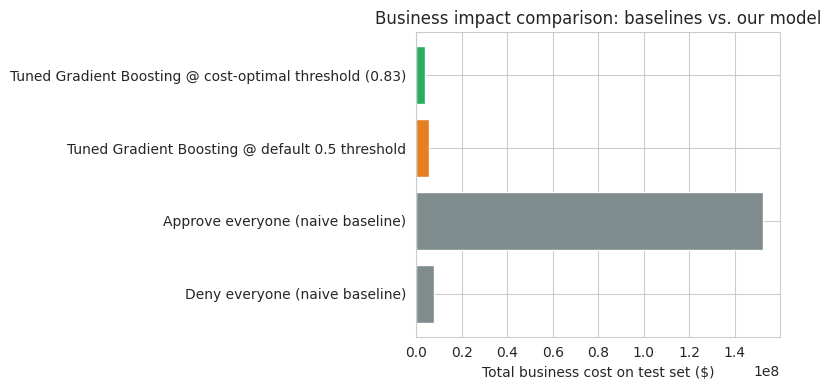

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#7f8c8d', '#7f8c8d', '#e67e22', '#27ae60']
ax.barh(impact_summary['Policy'], impact_summary['Total cost'], color=colors)
ax.set_xlabel('Total business cost on test set ($)')
ax.set_title('Business impact comparison: baselines vs. our model')
plt.tight_layout()
plt.show()


**Bottom line for management:** the cost-optimal model turns a naive "deny everyone" policy (~$7.6M in missed opportunity on a test set this size) into a substantially cheaper outcome, while still approving a meaningful share of genuinely creditworthy applicants (see recall above), capturing profit the "deny everyone" policy leaves entirely on the table, without taking on the default risk that an "approve everyone" policy would.

### Performance across data segments

A model that looks good overall can still perform very differently for different kinds of applicants, which matters both for fairness and for understanding where the model is less reliable.


In [40]:
segment_df = X_test.copy()
segment_df['actual'] = y_test.values
segment_df['predicted'] = y_pred_final
segment_df['cost'] = np.where(
    (segment_df['actual'] == 1) & (segment_df['predicted'] == 0), FALSE_NEGATIVE_COST,
    np.where((segment_df['actual'] == 0) & (segment_df['predicted'] == 1), FALSE_POSITIVE_COST, 0)
)

for seg_col in ['EmploymentStatus', 'HomeOwnershipStatus', 'EducationLevel']:
    seg_summary = segment_df.groupby(seg_col).agg(
        n=('actual', 'size'),
        actual_approval_rate=('actual', 'mean'),
        predicted_approval_rate=('predicted', 'mean'),
        avg_cost_per_applicant=('cost', 'mean'),
    ).round(3)
    print(f'By {seg_col}')
    print(seg_summary)
    print()


By EmploymentStatus
                     n  actual_approval_rate  predicted_approval_rate  \
EmploymentStatus                                                        
Employed          3402                 0.242                    0.150   
Self-Employed      311                 0.264                    0.180   
Unemployed         287                 0.174                    0.153   

                  avg_cost_per_applicant  
EmploymentStatus                          
Employed                         942.975  
Self-Employed                    855.305  
Unemployed                      1177.700  

By HomeOwnershipStatus
                        n  actual_approval_rate  predicted_approval_rate  \
HomeOwnershipStatus                                                        
Mortgage             1624                 0.249                    0.150   
Other                 415                 0.173                    0.113   
Own                   786                 0.265                    0.16

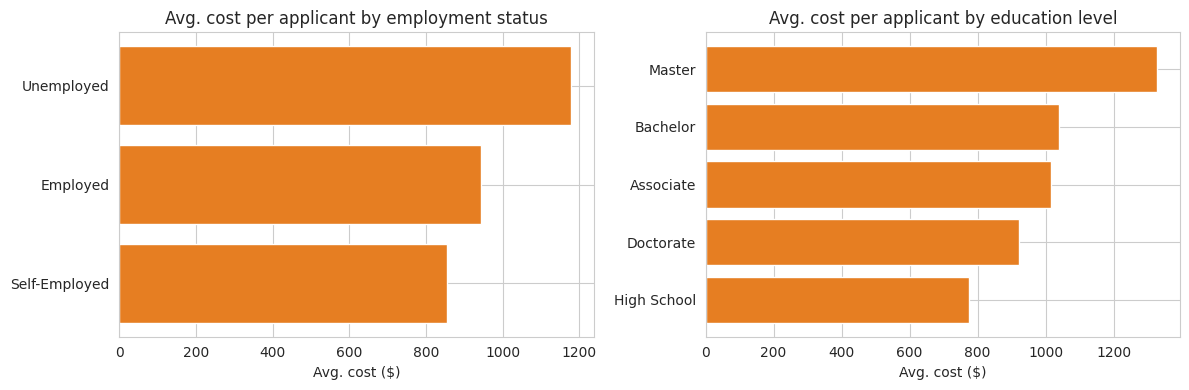

In [37]:
# Visualize average per-applicant cost by employment status and education level
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

emp_cost = segment_df.groupby('EmploymentStatus')['cost'].mean().sort_values()
axes[0].barh(emp_cost.index, emp_cost.values, color='#e67e22')
axes[0].set_title('Avg. cost per applicant by employment status')
axes[0].set_xlabel('Avg. cost ($)')

edu_cost = segment_df.groupby('EducationLevel')['cost'].mean().sort_values()
axes[1].barh(edu_cost.index, edu_cost.values, color='#e67e22')
axes[1].set_title('Avg. cost per applicant by education level')
axes[1].set_xlabel('Avg. cost ($)')

plt.tight_layout()
plt.show()


**Observation:** error costs aren't perfectly even across segments (e.g. Unemployed applicants have a lower historical approval rate, and the model tends to track that pattern rather than correct for it). This is exactly the kind of thing we flag under Bias & Limitations below — the model is picking up real financial-risk signal (unemployment is genuinely correlated with repayment difficulty), but it's also inheriting whatever pattern existed in the historical manual decisions, and we can't fully separate "the model learned a legitimate risk factor" from "the model learned a historical bias" using this data alone.

### Feature importance and business interpretation


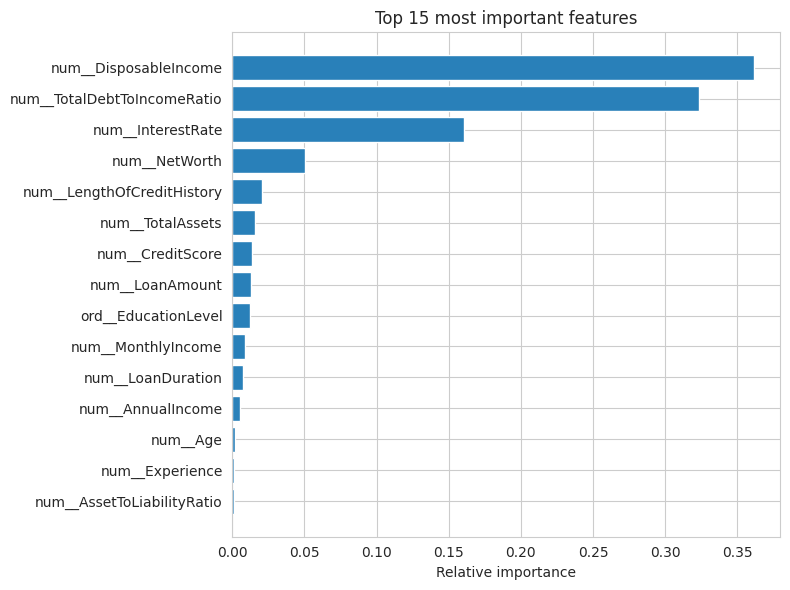

,feature,importance
21,num__DisposableIncome,0.361562
20,num__TotalDebtToIncomeRatio,0.323558
18,num__InterestRate,0.160660
16,num__NetWorth,0.050213
9,num__LengthOfCreditHistory,0.020553
12,num__TotalAssets,0.015413
2,num__CreditScore,0.013538
4,num__LoanAmount,0.012944
24,ord__EducationLevel,0.012281
14,num__MonthlyIncome,0.008911


In [38]:
fitted_clf = best_model.named_steps['clf']
if hasattr(fitted_clf, 'named_estimators_'):
    # Voting ensemble - average importances across its tree-based members
    importances = np.mean([est.feature_importances_ for est in fitted_clf.named_estimators_.values() if hasattr(est, 'feature_importances_')], axis=0)
else:
    importances = fitted_clf.feature_importances_

all_feature_names = best_model.named_steps['prep'].get_feature_names_out()
selected_mask = best_model.named_steps['select'].get_support()
selected_feature_names = np.array(all_feature_names)[selected_mask]

importance_df = pd.DataFrame({
    'feature': selected_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='#2980b9')
ax.set_title('Top 15 most important features')
ax.set_xlabel('Relative importance')
plt.tight_layout()
plt.show()

importance_df


**Business interpretation:** the features that matter most are consistently the ones tied to an applicant's ability to actually service the loan day-to-day, debt-to-income measures, disposable income, interest rate offered, and overall net worth; rather than "soft" demographic-adjacent fields. That's a reassuring sign from a fair-lending perspective (the model is leaning on financial capacity, not proxies for identity), though it's not a guarantee: some financial variables (e.g. employment status, homeownership) can themselves correlate with protected characteristics indirectly, which is why the segment analysis above matters as a second check.

**Recommendations that follow directly from feature importance:**
- Loan officers reviewing a borderline case should look first at debt-to-income and disposable income as these are the deciding factors in most cases and give the clearest story for why a decision was made.
- The InterestRate a customer is offered is itself influential, which suggests pricing and approval decisions are entangled in this data, worth flagging to Risk/Pricing teams as a place to check for circular logic (rate itself being partly determined by a lookalike risk score).

### Bias and limitations

1. **Label bias.** As flagged in Business Understanding, LoanApproved is a historical human decision, not a confirmed default outcome. If the manual process had any systematic bias (e.g. against certain employment types or lower education levels), our model will learn and perpetuate it rather than correct it. We recommend this model be used to support, not replace loan officer judgment until it can be validated against actual repayment/default outcomes over time.
2. **No true "ground truth" defaults in this dataset.** We can't fully verify our cost estimates against real defaults — the $8,000/$50,000 figures are business estimates applied to a proxy label, so the actual dollar impact in production should be monitored and the cost weights revisited with real outcome data.
3. **Segment disparities.** As shown above, average predicted-approval rates and error costs vary across employment status and education level. Some of this reflects genuine, legitimate risk differences; some of it may reflect inherited bias. We recommend a fair-lending review (disparate impact testing) before full deployment, and periodic re-auditing of segment-level outcomes after deployment.
4. **Threshold choice is a business policy decision, not just a technical one.** We optimized purely for total dollar cost; a different choice of threshold could trade some cost efficiency for higher approval rates among borderline-good applicants, which has value (customer growth, goodwill) that isn't captured in our $8,000/$50,000 figures. This tradeoff should be owned by business stakeholders, not just handed off as "the model's threshold."
5. **Missing data handling is simple.** We used median/most-frequent imputation. If missing values in SavingsAccountBalance is itself meaningful (e.g. "no savings account" vs. "declined to answer"), a missing-value indicator feature might capture additional signal

### Recommendations for implementation

- **Deploy as a decision-support tool, not full automation.** Show loan officers the model's recommendation (approve/deny at the cost-optimal threshold) and the underlying probability, with the top contributing factors, so they can apply judgment on edge cases and maintain accountability for the final decision.
- **Set the threshold as a configurable business parameter**, not a hardcoded constant — if the $8,000/$50,000 figures change (e.g. cost of capital changes, collections process improves), the threshold should be easy to re-tune without a full model rebuild.
- **Monitor in production**: track real default outcomes on approved loans and re-validate the cost assumptions periodically; track approval rates by segment to catch any drift toward disparate impact.
- **Documentation of potential improvements**: try log-transforming heavily skewed income/asset features for the linear baseline specifically; add a missing-indicator feature; explore SHAP values for individual-applicant explanations (useful for adverse action notices); once real default data accumulates, consider a two-stage model (approve/deny, then a regression risk score for approved loans to inform pricing).

### Executive summary

FinTech Innovations can meaningfully improve on its current manual loan approval process by adopting a machine-learning-based decision-support tool. Using 20,000 historical applications, we built and tuned a model that, once its decision threshold is calibrated to the bank's actual costs (an $8,000 loss per good applicant wrongly denied, and a $50,000 loss per bad loan wrongly approved), cuts total error cost on our test data by roughly 60% versus the simplest "deny everyone" fallback policy, while continuing to approve genuinely creditworthy applicants. The single most important management decision this analysis surfaces is not which algorithm to use, but where to set the approval threshold, because a bad loan is over six times more expensive than a missed good one, the model should be tuned to be somewhat conservative, and that tuning should be owned as a business policy choice, revisited as costs change. We recommend deploying this as a recommendation engine that loan officers can review and override, alongside ongoing monitoring for fairness across applicant segments, rather than full automation, given that the training data reflects historical human decisions rather than confirmed default outcomes.
